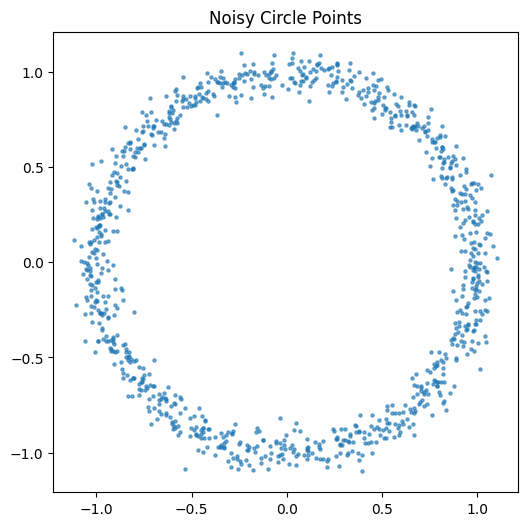

In [1]:
import torch
import matplotlib.pyplot as plt 
import numpy as np

torch.manual_seed(1234)

t = torch.linspace(0., 2 * 3.14, 1000).unsqueeze(-1)  # shape (1000, 1)
noise = torch.randn(1000, 2) * 0.05
points = torch.cat([torch.cos(t), torch.sin(t)], dim=1) + noise

plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0].numpy(), points[:, 1].numpy(), s=5, alpha=0.6)
plt.gca().set_aspect('equal')
plt.title("Noisy Circle Points")
plt.show()

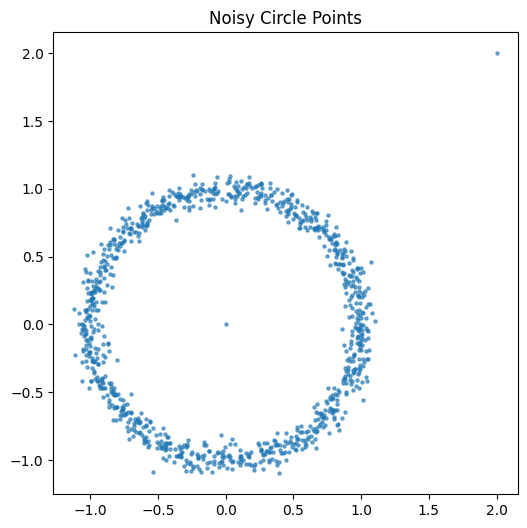

In [2]:
points_with_outliers = torch.cat(
    [
        points,
        torch.tensor([[0., 0.], [2., 2.]])
    ],
    dim=0
)

plt.figure(figsize=(6, 6))
plt.scatter(points_with_outliers[:, 0].numpy(), points_with_outliers[:, 1].numpy(), s=5, alpha=0.6)
plt.gca().set_aspect('equal')
plt.title("Noisy Circle Points")
plt.show()


In [ ]:
shuffled_points = points[torch.randperm(points.size(0))]

In [4]:
import torch.nn as nn

encoder = nn.Sequential(
    nn.Linear(2, 16),   
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

decoder = nn.Sequential(
    nn.Linear(1, 16),   # vstup je 1D latentný vektor
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 2)    # výstup späť do 2D
)

In [5]:
import torch.optim as optim

# Autoencoder ako Sequential zo zložených encoder + decoder
autoencoder = nn.Sequential(
    encoder,
    decoder
)

# Loss funkcia
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)

In [6]:
from torch.utils.data import TensorDataset, DataLoader, random_split

# Dataset a DataLoader
dataset = TensorDataset(shuffled_points, shuffled_points)  # x aj y sú rovnaké
val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Tréningový loop
epochs = 500
for epoch in range(epochs):
    autoencoder.train()
    train_loss = 0.0
    for x, y in train_loader:
        optimizer.zero_grad()
        outputs = autoencoder(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
    
    train_loss /= train_size

    # Validácia
    autoencoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            outputs = autoencoder(x)
            loss = criterion(outputs, y)
            val_loss += loss.item() * x.size(0)
    val_loss /= val_size

    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch [1/500] Train Loss: 0.5234 | Val Loss: 0.5153
Epoch [50/500] Train Loss: 0.0187 | Val Loss: 0.0425
Epoch [100/500] Train Loss: 0.0089 | Val Loss: 0.0189
Epoch [150/500] Train Loss: 0.0054 | Val Loss: 0.0136
Epoch [200/500] Train Loss: 0.0036 | Val Loss: 0.0113
Epoch [250/500] Train Loss: 0.0025 | Val Loss: 0.0067
Epoch [300/500] Train Loss: 0.0021 | Val Loss: 0.0081
Epoch [350/500] Train Loss: 0.0038 | Val Loss: 0.0121
Epoch [400/500] Train Loss: 0.0016 | Val Loss: 0.0035
Epoch [450/500] Train Loss: 0.0046 | Val Loss: 0.0122
Epoch [500/500] Train Loss: 0.0024 | Val Loss: 0.0042


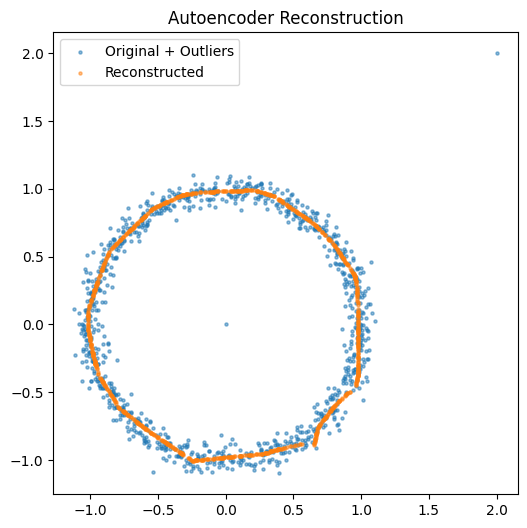

In [7]:
# Prepni model do eval módu
autoencoder.eval()

# Rekonštrukcia
with torch.no_grad():
    reconstructed_points = autoencoder(points_with_outliers)

# Plot pôvodných vs. rekonštruovaných bodov
plt.figure(figsize=(6, 6))
plt.scatter(points_with_outliers[:, 0].numpy(),
            points_with_outliers[:, 1].numpy(),
            s=5, alpha=0.5, label="Original + Outliers")
plt.scatter(reconstructed_points[:, 0].numpy(),
            reconstructed_points[:, 1].numpy(),
            s=5, alpha=0.5, label="Reconstructed")
plt.gca().set_aspect('equal')
plt.legend()
plt.title("Autoencoder Reconstruction")
plt.show()
